<a href="https://colab.research.google.com/github/CactusDataMafia/Yadro_AI_schoo_sem_1_ML/blob/main/2_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задача 1

Реализовать класс для работы с линейной регрессией

In [32]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from sklearn.base import BaseEstimator, RegressorMixin

class MyLinearRegression:
    """
    Parameters
    ----------
    regularization : {None, 'l1', 'l2', 'l1l2'}, default=None
        Какую регуляризацию добавить к модели. Если значение `None`, то без регуляризации.

    weight_calc : {'matrix', 'gd', 'sgd'}, default='matrix'
        Каким образом вычислять вектор весов: матрично ('matrix'), градиентным спуском ('gd') или стохастическим градиентным спуском ('sgd'). При этом, при 'l1' или 'l1l2' нельзя использовать параметр 'matrix'.

    Attributes
    ----------
    coef_ : Вектор коэффициентов размера (p, 1), где p — количество признаков.
    intercept_ : Значение коэффициента, отвечающего за смещение
    """

    def __init__(self, regularization=None, weight_calc='matrix', lambda_1=None, lambda_2=None, batch_size=20, learning_rate=0.001, epochs=50, tol=1e-5):
        if regularization not in [None, 'l1', 'l2', 'l1l2']:
          raise TypeError(f"Параметр regularization не может принимать значение '{regularization}'")
        if weight_calc not in ['matrix', 'gd', 'sgd']:
          raise TypeError(f"Параметр weight_calc не может принимать значение '{weight_calc}'")
        if regularization in ['l1', 'l1l2'] and lambda_1 is None:
          raise TypeError(f"Значение коэффициента регулризации l1 не задано")
        if regularization in ['l2', 'l1l2'] and lambda_2 is None:
          raise TypeError(f"Значение коэффициента регулризации l2 не задано")
        if weight_calc == "matrix" and regularization in ("l1", "l1l2"):
          raise TypeError("при регуляризации вида l1 или l1l2 нельзя использовать параметр weight_calc matrix")

        self.regularization = regularization
        self.weight_calc = weight_calc
        self.lambda_1 = lambda_1 if lambda_1 is not None else 0.0
        self.lambda_2 = lambda_2 if lambda_2 is not None else 0.0
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.tol = tol
        self.intercept_ = None
        self.coef_ = None
        self.weights = None


    def f_and_grad(self, w, X, y, reg_type):
      n = X.shape[0]

      predict = X @ w
      error = predict - y

      w_reg = np.copy(w)
      w_reg[0] = 0

      if reg_type is None:
        loss = (1 / n) * np.sum(error ** 2)
        grad = (2 / n) * (X.T @ error)
      elif reg_type == "l2":
        loss = (1 / n) * np.sum(error ** 2) + self.lambda_2 * np.sum(w_reg ** 2)
        grad = (2 / n) * (X.T @ error) + 2 * self.lambda_2 * w_reg
      elif reg_type == "l1":
        loss = (1 / n) * np.sum(error ** 2) + self.lambda_1 * np.sum(np.abs(w_reg))
        grad = (2 / n) * (X.T @ error) + self.lambda_1 * np.sign(w_reg)
      elif reg_type == "l1l2":
        loss = (1 / n) * np.sum(error ** 2) + self.lambda_1 * np.sum(np.abs(w_reg)) + self.lambda_2 * np.sum(w_reg ** 2)
        grad = (2 / n) * (X.T @ error) + self.lambda_1 * np.sign(w_reg) + 2 * self.lambda_2 * w_reg
      return loss, grad


    def fit(self, X: pd.DataFrame, y: pd.DataFrame):
      x_vals = np.array(X)
      y_vals = np.array(y)

      if y_vals.ndim == 2:
            y_vals = y_vals.ravel()

      r, c = x_vals.shape
      new_X = np.hstack((np.ones((r, 1)), x_vals))

      if self.weight_calc == "matrix":
        xtx = new_X.T @ new_X
        xty = new_X.T @ y_vals
        if self.regularization == None:
          self.weights = np.linalg.inv(xtx) @ xty
        if self.regularization == "l2":
          I = np.eye(c + 1)
          I[0, 0] = 0
          self.weights = np.linalg.inv(xtx + self.lambda_2 * I) @ xty

      elif self.weight_calc == "gd":
        w_start = np.random.normal(size=c + 1)
        res = minimize(fun=self.f_and_grad, x0=w_start, jac=True, args=(new_X, y_vals, self.regularization), tol=self.tol)
        self.weights = res.x
      elif self.weight_calc == "sgd":
        w_start = np.random.normal(size=c + 1)
        w_curr = w_start.copy()
        for _ in range(self.epochs):
          order = np.random.permutation(r)
          w_prev_epoch = w_curr.copy()
          for i in range(0, r, self.batch_size):
            data = order[i:i + self.batch_size]
            _, grad = self.f_and_grad(w_curr, new_X[data], y_vals[data], self.regularization)
            w_curr = w_curr - self.learning_rate * grad
          weight_change = np.linalg.norm(w_curr - w_prev_epoch)
          if weight_change < self.tol:
            break
        self.weights = w_curr

      self.intercept_ = self.weights[0]
      self.coef_ = self.weights[1:]


    def predict(self, X: np.array, ss=True):
        x_vals = np.array(X)
        pred = x_vals @ self.coef_ + self.intercept_
        return pred

    def score(self, X: np.array, y: np.array):
      y_true = np.array(y).ravel()
      if y_true.ndim == 2:
            y_true = y_true.ravel()
      y_pred = self.predict(X)
      tss = np.sum((y_true - y_true.mean()) ** 2)
      rss = np.sum((y_true - y_pred) ** 2)
      return 1 - (rss / tss)

Используя датасет про автомобили (целевой признак — price), сравнить (качество, скорость обучения и предсказания, важность признаков) модели `MyLinearRegression` с различными гиперпараметрами, сделать выводы. На этом же датасете сравнить модель `MyLinearRegression` с библиотечной реализацией из `sklearn`, составить таблицу(ы) (графики) результатов сравнения (качество, скорость обучения и предсказания, важность признаков).

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, SGDRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import time
from functools import wraps

In [34]:
df = pd.read_csv("/content/Used_fiat_500_in_Italy_dataset.csv")

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            380 non-null    object 
 1   engine_power     380 non-null    int64  
 2   transmission     380 non-null    object 
 3   age_in_days      380 non-null    int64  
 4   km               380 non-null    int64  
 5   previous_owners  380 non-null    int64  
 6   lat              380 non-null    float64
 7   lon              380 non-null    float64
 8   price            380 non-null    int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 26.8+ KB


In [36]:
df.describe(include="all")

,model,engine_power,transmission,age_in_days,km,previous_owners,lat,lon,price
count,380,380.000000,380,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
unique,4,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
top,lounge,NaN,manual,NaN,NaN,NaN,NaN,NaN,NaN
freq,212,NaN,355,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,73.015789,NaN,3310.265789,102196.250000,1.510526,44.257712,10.742644,5881.655263
std,NaN,9.984672,NaN,1437.555063,47115.355234,0.560244,1.767518,2.167753,2170.617946
min,NaN,69.000000,NaN,91.000000,4981.000000,1.000000,37.510872,7.320720,2890.000000
25%,NaN,69.000000,NaN,3097.250000,76611.750000,1.000000,43.514196,9.159140,4600.000000
50%,NaN,69.000000,NaN,3927.000000,112000.000000,1.000000,45.069679,10.301505,5000.000000
75%,NaN,69.000000,NaN,4322.000000,135000.000000,2.000000,45.556942,12.346788,5500.000000


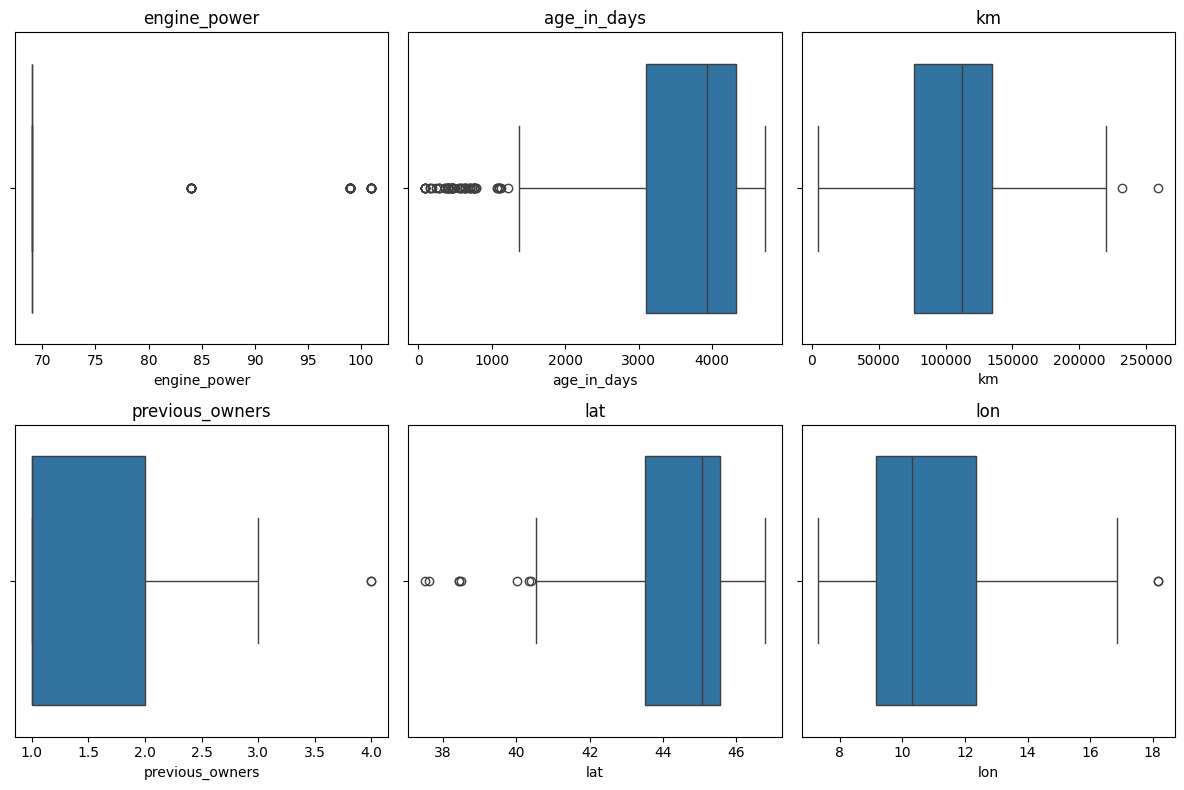

In [37]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

fig, axs = plt.subplots(2, 3, figsize=(12, 8))

for indx, axi in enumerate(axs.flat):
  sns.boxplot(data=df, x=num_cols[indx], ax=axi)
  axi.set_title(f"{num_cols[indx]}")

plt.tight_layout()
plt.show()

In [38]:
enc = OneHotEncoder(drop="first", handle_unknown="ignore")
enc.fit(df[["model", "transmission"]])

feature_names = enc.get_feature_names_out(["model", "transmission"])

X_cat = pd.DataFrame(
    enc.transform(df[["model", "transmission"]]).toarray(),
    columns=feature_names,
    index=df.index
)
df = df.drop(columns=["model", "transmission"])
X = pd.concat((X_cat, df.drop(columns="price")), axis=1)
y = df["price"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=21)
columns = X_train.columns

In [40]:
# scaler = RobustScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
def call_lr(model_obj, columns=columns, params_grid=None, **model_params):
  current_params = model_params.copy()
  if params_grid:
    best_model_score = -np.inf
    best_model_time = None
    best_model_imp_dict = None
    best_model_params_comb = None
    best_model = None

    all_params_comb = ParameterGrid(params_grid)
    for params_comb in all_params_comb:
      current_params.update(params_comb)
      lr = model_obj(**current_params)
      start = time.perf_counter()
      lr.fit(X_train_scaled, y_train)
      # y_pred = lr.predict(X_test_scaled)
      score = lr.score(X_test_scaled, y_test)
      end = time.perf_counter()
      delta = end - start
      if score > best_model_score:
        best_model_score = score
        best_model_time = delta
        best_model_imp_dict = dict(zip(columns, lr.coef_.flatten()))
        best_model_params_comb = params_comb
        best_model = lr
    return best_model_params_comb, best_model_score, best_model_time, best_model_imp_dict, best_model
  else:
    lr = model_obj(**model_params)
    start = time.perf_counter()
    lr.fit(X_train_scaled, y_train)
    # y_pred = lr.predict(X_test_scaled)
    score = lr.score(X_test_scaled, y_test)
    end = time.perf_counter()
    delta = end - start
    imp_dict = dict(zip(columns, lr.coef_.flatten()))
    return score, delta, imp_dict

In [42]:
lambdas_list = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
learning_rate_list=[0.0001, 0.001, 0.01]
params_grid_l1 = {
    "regularization": ["l1"],
    "lambda_1": lambdas_list
}

params_grid_l2 = {
    "regularization": ["l2"],
    "lambda_2": lambdas_list
}

params_grid_l1l2 = {
    "regularization": ["l1l2"],
    "lambda_1": lambdas_list,
    "lambda_2": lambdas_list
}
params_grid_lib = {
    "alpha": lambdas_list
}

In [110]:
imp_dicts_my = {}
scores_my = {}
times_my = {}

imp_dicts_lib = {}
scores_lib = {}
times_lib = {}

### weight_calc = matrix

In [111]:
score, delta, imp_dict = call_lr(MyLinearRegression, weight_calc="matrix")

print(f"Аналитическое решение выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_my["analytical"] = delta
scores_my["analytical"] = score
imp_dicts_my["analytical"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Аналитическое решение выполнилось за 0.0031 секунд

R^2 score: 0.8152

age_in_days -1617.4254491120566
km -493.5732004701309
lon 275.4907187451275
lat 256.96936153187625
model_pop 98.9574311114305
model_sport 95.40806441021503
transmission_manual -80.12545898290364
model_star 33.25794409519227
engine_power 30.56060848659586
previous_owners -1.6481079550219988


In [112]:
score, delta, imp_dict = call_lr(LinearRegression)

print(f"Аналитическое решение выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_lib["analytical"] = delta
scores_lib["analytical"] = score
imp_dicts_lib["analytical"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Аналитическое решение выполнилось за 0.0099 секунд

R^2 score: 0.8152

age_in_days -1617.4254491120562
km -493.57320047013127
lon 275.49071874512725
lat 256.96936153187585
model_pop 98.9574311114295
model_sport 95.40806441021482
transmission_manual -80.12545898290256
model_star 33.25794409519226
engine_power 30.560608486595868
previous_owners -1.6481079550228408


### weight_calc = gd

#### L1

In [113]:
params, score, delta, imp_dict, best_model = call_lr(MyLinearRegression,
                                 params_grid=params_grid_l1,
                                 weight_calc="gd",
                                 lambda_1=0.0)
print(f"Лучшая комбинация параметров: {params}\n")
print(f"Gd решение l1 выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

# best_model.fit(X_train_scaled, y_train)
# best_model.score(X_test_scaled, y_test)

times_my["l1 gd"] = delta
scores_my["l1 gd"] = score
imp_dicts_my["l1 gd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Лучшая комбинация параметров: {'lambda_1': 100, 'regularization': 'l1'}

Gd решение l1 выполнилось за 0.0122 секунд

R^2 score: 0.8330

age_in_days -1581.1904675263015
km -434.66042332020055
lon 57.45492144134431
lat 52.366377096256976
model_sport 18.280368733994084
transmission_manual -15.966078396691497
model_pop 12.19269419532331
model_star 1.6662321919701992
engine_power 0.6959884895463095
previous_owners -0.17405817177109437


In [114]:
params, score, delta, imp_dict, best_model = call_lr(Lasso,
                                 params_grid=params_grid_lib)
print(f"Лучшая комбинация параметров: {params}\n")
print(f"Lasso решение  выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_lib["l1 gd"] = delta
scores_lib["l1 gd"] = score
imp_dicts_lib["l1 gd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Лучшая комбинация параметров: {'alpha': 100}

Lasso решение  выполнилось за 0.0024 секунд

R^2 score: 0.8345

age_in_days -1556.407241661866
km -394.78476885934197
model_pop 0.0
model_sport 0.0
model_star 0.0
transmission_manual -0.0
engine_power 0.0
previous_owners -0.0
lat 0.0
lon 0.0


#### L2

In [115]:
params, score, delta, imp_dict, best_model = call_lr(MyLinearRegression,
                                 params_grid=params_grid_l2,
                                 weight_calc="gd",
                                 lambda_2=0.0)
print(f"Лучшая комбинация параметров: {params}\n")
print(f"Gd решение l2 выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_my["l2 gd"] = delta
scores_my["l2 gd"] = score
imp_dicts_my["l2 gd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Лучшая комбинация параметров: {'lambda_2': 0.1, 'regularization': 'l2'}

Gd решение l2 выполнилось за 0.0059 секунд

R^2 score: 0.8246

age_in_days -1385.9084062764616
km -591.2971067970733
lon 199.93251217422227
lat 179.36898377592948
transmission_manual -71.35268281773021
model_sport 65.62238968886207
model_pop 59.888731253819856
model_star 45.7131801798384
engine_power 3.7933872107983193
previous_owners -1.1813762817539146


In [116]:
params, score, delta, imp_dict, best_model = call_lr(Ridge,
                                 params_grid=params_grid_lib)
print(f"Лучшая комбинация параметров: {params}\n")
print(f"Gd решение l2 выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_lib["l2 gd"] = delta
scores_lib["l2 gd"] = score
imp_dicts_lib["l2 gd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Лучшая комбинация параметров: {'alpha': 10}

Gd решение l2 выполнилось за 0.0021 секунд

R^2 score: 0.8203

age_in_days -1531.4109809853953
km -535.5801009518556
lon 247.41996580304237
lat 227.4137594036062
model_sport 84.89625278968656
model_pop 84.54883260151813
transmission_manual -77.34048890370673
model_star 37.84718637724157
engine_power 21.2893941222128
previous_owners -1.0795317145123338


#### L1L2

In [117]:
params, score, delta, imp_dict, best_model = call_lr(MyLinearRegression,
                                 params_grid=params_grid_l1l2,
                                 weight_calc="gd",
                                 lambda_1=0.0,
                                 lambda_2=0.0)
print(f"Лучшая комбинация параметров: {params}\n")
print(f"Gd решение l1l2 выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_my["l1l2 gd"] = delta
scores_my["l1l2 gd"] = score
imp_dicts_my["l1l2 gd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Лучшая комбинация параметров: {'lambda_1': 100, 'lambda_2': 0.1, 'regularization': 'l1l2'}

Gd решение l1l2 выполнилось за 0.0322 секунд

R^2 score: 0.8344

age_in_days -1355.4243782874507
km -551.5033322709431
lon 50.09826171034916
lat 37.102050972663406
model_star 17.553293752145674
transmission_manual -4.34479705213648
previous_owners -1.520885792694999
model_sport 1.4416917089222967
engine_power 0.17523497149974804
model_pop 0.05530266517633953


In [118]:
params, score, delta, imp_dict, best_model = call_lr(ElasticNet,
                                 params_grid=params_grid_lib)
print(f"Лучшая комбинация параметров: {params}\n")
print(f"Gd решение l1 выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_lib["l1l2 gd"] = delta
scores_lib["l1l2 gd"] = score
imp_dicts_lib["l1l2 gd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Лучшая комбинация параметров: {'alpha': 0.1}

Gd решение l1 выполнилось за 0.0028 секунд

R^2 score: 0.8223

age_in_days -1485.9089386466294
km -555.1536094252567
lon 232.33005708756392
lat 211.8878128606259
model_sport 78.99536613394908
model_pop 76.77016547075026
transmission_manual -75.58900734841747
model_star 40.26726038340798
engine_power 16.003130136982943
previous_owners -0.9425253818767074


### weight_calc = sgd

#### L1

In [119]:
params, score, delta, imp_dict, best_model = call_lr(MyLinearRegression,
                                 params_grid={**params_grid_l1, "learning_rate": learning_rate_list},
                                 weight_calc="sgd")
print(f"Лучшая комбинация параметров: {params}\n")
print(f"Sgd решение l1l2 выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_my["l1 sgd"] = delta
scores_my["l1 sgd"] = score
imp_dicts_my["l1 sgd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Лучшая комбинация параметров: {'lambda_1': 100, 'learning_rate': 0.01, 'regularization': 'l1'}

Sgd решение l1l2 выполнилось за 0.0283 секунд

R^2 score: 0.8330

age_in_days -1565.9916642504486
km -448.87558166229365
lon 67.50233590778626
lat 48.13304206608476
transmission_manual -21.66355992486899
model_sport 20.01887895069084
model_pop 16.406202659745478
model_star 11.247898277543614
engine_power 3.9191502562791865
previous_owners -0.5797861103618884


In [120]:
params, score, delta, imp_dict, best_model = call_lr(SGDRegressor,
                                 params_grid=params_grid_lib,
                                 penalty="l1")
print(f"Лучшая комбинация параметров: {params}\n")
print(f"SGDRegressor выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_lib["l1 sgd"] = delta
scores_lib["l1 sgd"] = score
imp_dicts_lib["l1 sgd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Лучшая комбинация параметров: {'alpha': 100}

SGDRegressor выполнилось за 0.0031 секунд

R^2 score: 0.8349

age_in_days -1521.3434183117668
km -425.1935188913412
model_pop 0.0
model_sport 0.0
model_star 0.0
transmission_manual 0.0
engine_power 0.0
previous_owners 0.0
lat 0.0
lon 0.0


#### L2

In [121]:
params, score, delta, imp_dict, best_model = call_lr(MyLinearRegression,
                                 params_grid={**params_grid_l2, "learning_rate": learning_rate_list},
                                 weight_calc="sgd")
print(f"Лучшая комбинация параметров: {params}\n")
print(f"Sgd решение l2 выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_my["l2 sgd"] = delta
scores_my["l2 sgd"] = score
imp_dicts_my["l2 sgd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Лучшая комбинация параметров: {'lambda_2': 0.1, 'learning_rate': 0.01, 'regularization': 'l2'}

Sgd решение l2 выполнилось за 0.0267 секунд

R^2 score: 0.8253

age_in_days -1382.2866395703436
km -583.522326974898
lon 201.85800218592462
lat 172.1133346936706
transmission_manual -71.71912026582794
model_sport 64.44378147610615
model_pop 57.44907453089961
model_star 44.66666902027154
engine_power -4.699719902654996
previous_owners -3.7129336585098063


/tmp/ipython-input-3042945751.py:60: RuntimeWarning: overflow encountered in scalar multiply
  loss = (1 / n) * np.sum(error ** 2) + self.lambda_2 * np.sum(w_reg ** 2)
/tmp/ipython-input-3042945751.py:60: RuntimeWarning: overflow encountered in square
  loss = (1 / n) * np.sum(error ** 2) + self.lambda_2 * np.sum(w_reg ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-3042945751.py:61: RuntimeWarning: overflow encountered in multiply
  grad = (2 / n) * (X.T @ error) + 2 * self.lambda_2 * w_reg
/tmp/ipython-input-3042945751.py:50: RuntimeWarning: invalid value encountered in matmul
  predict = X @ w
/tmp/ipython-input-3042945751.py:61: RuntimeWarning: invalid value encountered in matmul
  grad = (2 / n) * (X.T @ error) + 2 * self.lambda_2 * w_reg


In [122]:
params, score, delta, imp_dict, best_model = call_lr(SGDRegressor,
                                 params_grid=params_grid_lib,
                                 penalty="l2")
print(f"Лучшая комбинация параметров: {params}\n")
print(f"Sgd решение l2 выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_lib["l2 sgd"] = delta
scores_lib["l2 sgd"] = score
imp_dicts_lib["l2 sgd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Лучшая комбинация параметров: {'alpha': 0.1}

Sgd решение l2 выполнилось за 0.0028 секунд

R^2 score: 0.8247

age_in_days -1386.5190819100642
km -603.309403122307
lon 200.5089783860586
lat 173.43082588426532
transmission_manual -75.94620406397104
model_sport 64.83211686481216
model_pop 60.22860794771678
model_star 47.1042511828785
previous_owners -1.1722576575560197
engine_power 0.19854439839280397


#### L1L2

In [123]:
params, score, delta, imp_dict, best_model = call_lr(MyLinearRegression,
                                 params_grid={**params_grid_l1l2, "learning_rate": learning_rate_list},
                                 weight_calc="sgd")
print(f"Лучшая комбинация параметров: {params}\n")
print(f"Sgd решение l1l2 выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_my["l1l2 sgd"] = delta
scores_my["l1l2 sgd"] = score
imp_dicts_my["l1l2 sgd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

/tmp/ipython-input-3042945751.py:66: RuntimeWarning: overflow encountered in scalar multiply
  loss = (1 / n) * np.sum(error ** 2) + self.lambda_1 * np.sum(np.abs(w_reg)) + self.lambda_2 * np.sum(w_reg ** 2)
/tmp/ipython-input-3042945751.py:66: RuntimeWarning: overflow encountered in square
  loss = (1 / n) * np.sum(error ** 2) + self.lambda_1 * np.sum(np.abs(w_reg)) + self.lambda_2 * np.sum(w_reg ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-3042945751.py:67: RuntimeWarning: overflow encountered in multiply
  grad = (2 / n) * (X.T @ error) + self.lambda_1 * np.sign(w_reg) + 2 * self.lambda_2 * w_reg
/tmp/ipython-input-3042945751.py:67: RuntimeWarning: invalid value encountered in matmul
  grad = (2 / n) * (X.T @ error) + self.lambda_1 * np.sign(w_reg) + 2 * self.lambda_2 * w_reg
/tmp/ipython-input-3042945751.py:104: RuntimeWarning:

Лучшая комбинация параметров: {'lambda_1': 100, 'lambda_2': 0.01, 'learning_rate': 0.01, 'regularization': 'l1l2'}

Sgd решение l1l2 выполнилось за 0.0399 секунд

R^2 score: 0.8364

age_in_days -1566.1355826364124
km -469.5366414637321
lon 62.60317009010588
model_sport 47.76589669020843
lat 40.94218451356825
transmission_manual -21.754302834829534
previous_owners 16.73949339229299
engine_power -13.236836917500304
model_star 6.383721036452924
model_pop 1.2868951069283554


In [124]:
params, score, delta, imp_dict, best_model = call_lr(SGDRegressor,
                                 params_grid=params_grid_lib,
                                 penalty="elasticnet")
print(f"Лучшая комбинация параметров: {params}\n")
print(f"Sgd решение l1l2 выполнилось за {delta:.4f} секунд\n")
print(f"R^2 score: {score:.4f}\n")
for k, v in sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True):
  print(k, v)

times_lib["l1l2 sgd"] = delta
scores_lib["l1l2 sgd"] = score
imp_dicts_lib["l1l2 sgd"] = (dict(sorted(imp_dict.items(), key=lambda x: np.abs(x[1]), reverse=True)))

Лучшая комбинация параметров: {'alpha': 0.1}

Sgd решение l1l2 выполнилось за 0.0037 секунд

R^2 score: 0.8239

age_in_days -1407.751343951903
km -585.5570719157967
lon 204.9869943219657
lat 187.98318332729946
transmission_manual -75.83753461167967
model_sport 69.23724509730746
model_pop 64.5211831216372
model_star 44.82797887936477
engine_power 8.593266107530471
previous_owners 1.3219761932386227


### Результаты

In [125]:
df_times_my = pd.DataFrame(data=list(times_my.items()), columns=["Model", "compute time"])
df_times_lib = pd.DataFrame(data=list(times_lib.items()), columns=["Model", "compute time"])
df_times_my["implementation"] = "custom"
df_times_lib["implementation"] = "sklearn"
df_time = pd.concat((df_times_my, df_times_lib), ignore_index=True)

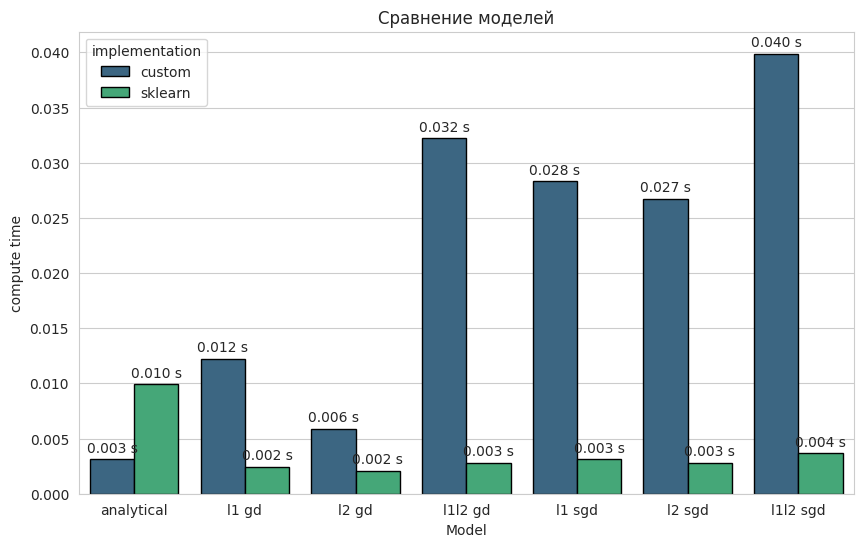

In [126]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_time, x='Model', y='compute time', hue='implementation', palette='viridis', edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f s', padding=3)

plt.title('Сравнение моделей')
# plt.grid(axis='y', alpha=0.5)
plt.show()

In [127]:
df_scores_my = pd.DataFrame(data=list(scores_my.items()), columns=["Model", "score"])
df_scores_lib = pd.DataFrame(data=list(scores_lib.items()), columns=["Model", "score"])
df_scores_my["implementation"] = "custom"
df_scores_lib["implementation"] = "sklearn"
df_score = pd.concat((df_scores_my, df_scores_lib), ignore_index=True)

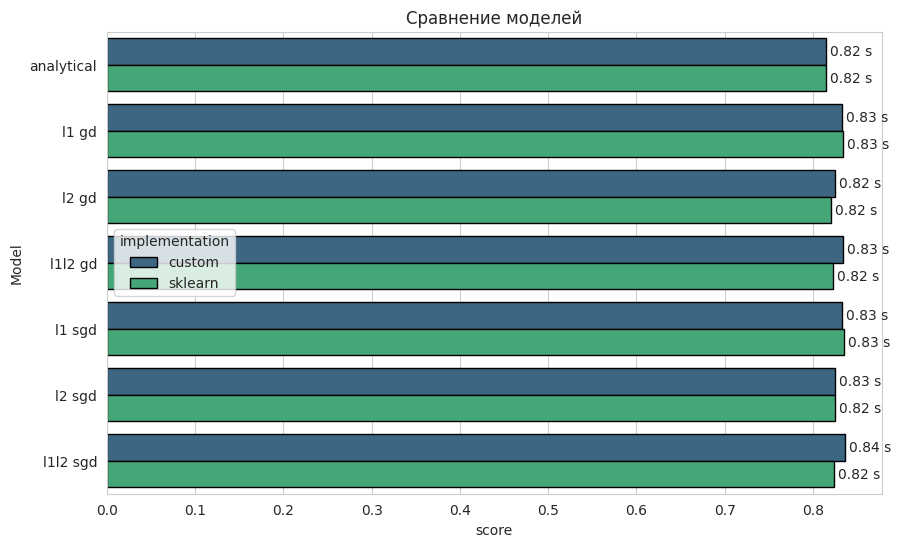

In [128]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_score, x='score', y='Model', hue='implementation', palette='viridis', edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f s', padding=3)

plt.title('Сравнение моделей')
# plt.grid(axis='y', alpha=0.5)
plt.show()

In [129]:
def dict_to_df(data, source):
  df = pd.DataFrame(data).T
  df.index.name = 'Model'
  df = pd.melt(df.reset_index(), id_vars=["Model"],  var_name='Coefficient', value_name='Value')
  df["Implementation"] = source
  return df

In [130]:
imp_dicts_my = dict_to_df(imp_dicts_my, "custom")
imp_dicts_lib = dict_to_df(imp_dicts_lib, "sklearn")

In [131]:
df_imp_dicts = pd.concat((imp_dicts_my, imp_dicts_lib), ignore_index=True)

In [138]:
model_names = df_imp_dicts['Model'].unique()

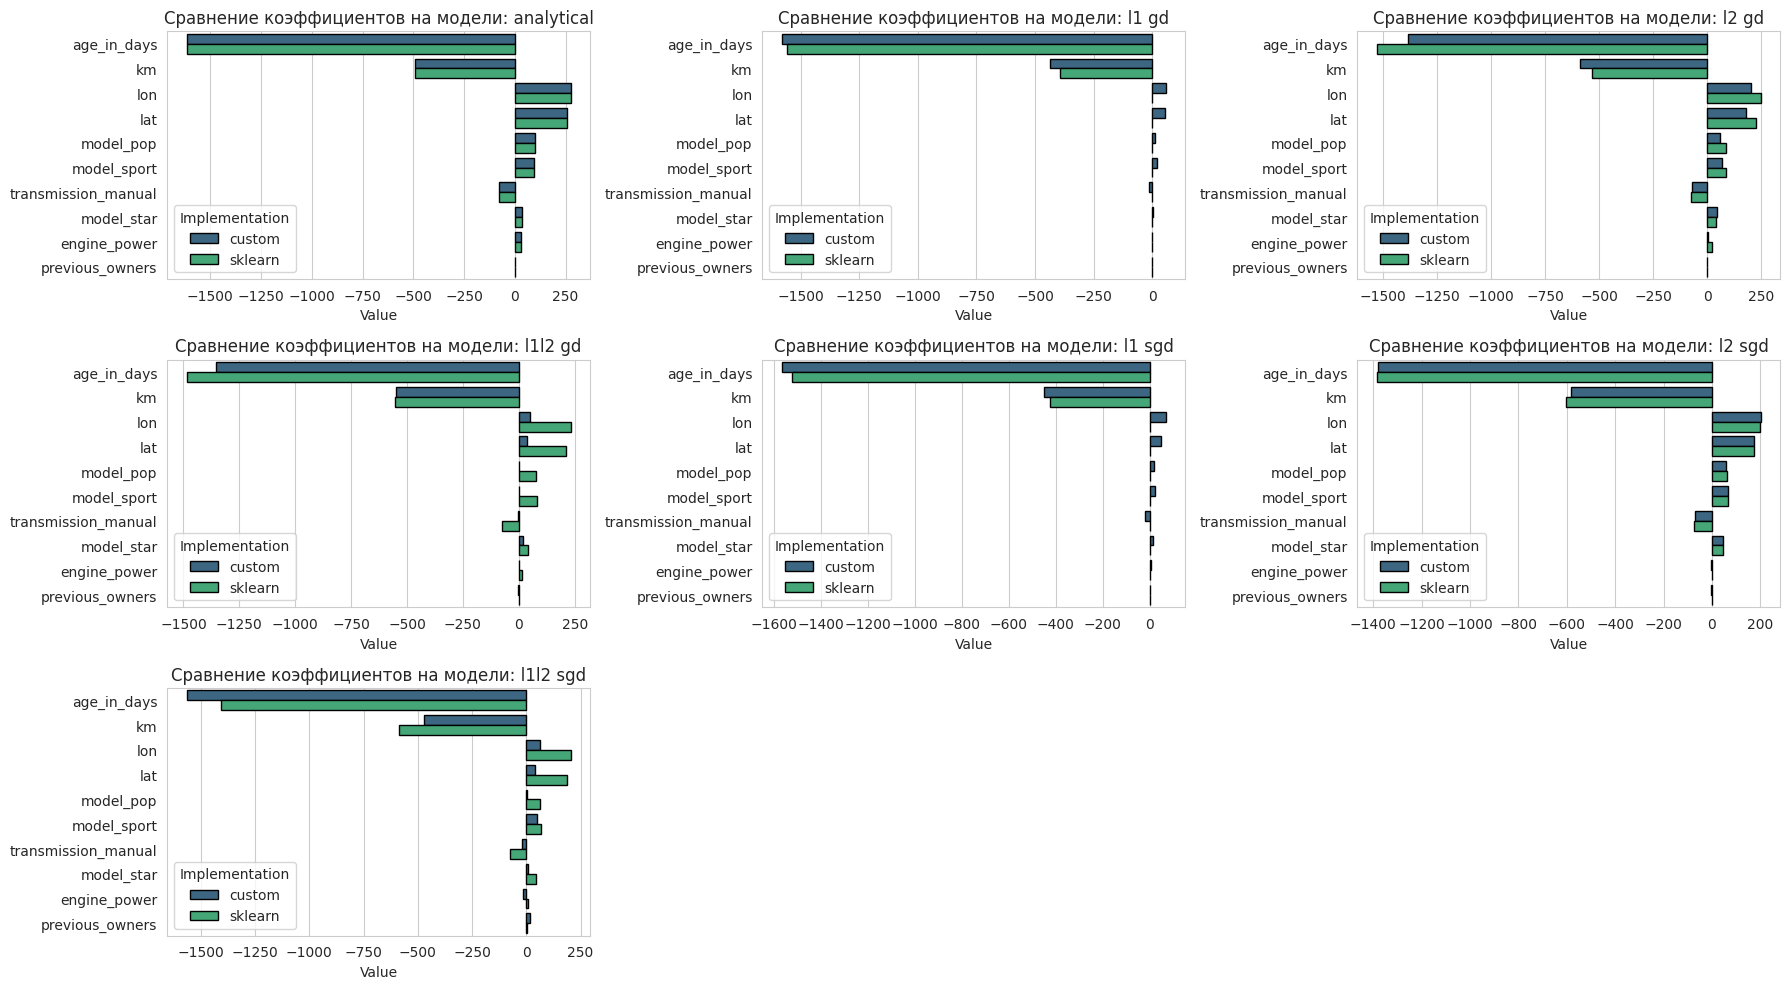

In [147]:
sns.set_style("whitegrid")

n_rows, n_cols = 3, 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axs_indx = axs.flatten()

for indx, model in enumerate(model_names):
  axi=axs_indx[indx]
  data_per_model = df_imp_dicts.loc[df_imp_dicts['Model'] == model]
  g = sns.barplot(
      data=data_per_model,
      x="Value",
      y="Coefficient",
      hue="Implementation" ,
      palette='viridis',
      edgecolor='black',
      ax=axi
  )
  axi.set_title(f"Сравнение коэффициентов на модели: {model}")
  axi.set_ylabel("")

for j in range(indx + 1, n_rows * n_cols):
    axs_indx[j].set_visible(False)

plt.tight_layout()
plt.show()

## Задача 2

[Соревнование на Kaggle](https://kaggle.com/competitions/yadro-regression-2025)